In [7]:
"""Load all .pkl files from save_game_temp, ordered by timestamp (YYYYMMDD_HHMMSS)."""
import pandas as pd

from analysis.savegame import (
    build_save_comparison_df,
    get_religion_data,
    merge_saves_with_location_data,
    resolve_pkl_dir,
)

# None = auto (newest playthrough), or set path directly
# PKL_PATH = "C:/Development/ProsperPerishCalcs/analysis/savegame/notebooks/save_game_temp/f3d0f1ca_a56c_42ea_acc9_4c4a7c4a7a01"
PKL_PATH = None
first_savegame = 0   # None = from start
last_savegame = 100  # None = to end

pkl_dir = resolve_pkl_dir(PKL_PATH)
pkl_files = sorted(pkl_dir.glob("*.pkl"), key=lambda p: p.stem)[first_savegame:last_savegame]
saves = {p.stem: pd.read_pickle(p) for p in pkl_files}
# Merge with full location data (development, rank, food, topography, etc.)
saves = merge_saves_with_location_data(saves)
print(f"Loaded {len(saves)} snapshots from {pkl_dir}: {list(saves.keys())[:5]}{'...' if len(saves) > 5 else ''}")

Loaded 34 snapshots from C:\Development\ProsperPerishCalcs\analysis\savegame\notebooks\save_game_temp\6c417b66_d3bd_40dc_8668_ecc75dc5c68d: ['20260321_200814', '20260321_200939', '20260321_201109', '20260321_201244', '20260321_201423']...


In [13]:
"""Config: pick any column for groupby. Change comparison, metric, n, order freely."""
if not saves:
    raise FileNotFoundError("No .pkl files in save_game_temp. Run the processor first.")
sample = next(iter(saves.values()))
available_group_cols = [c for c in sample.columns if c not in ("slug", "location_id", "name")]
print("Available group-by columns:", available_group_cols)

comparison = "macro_region_pkl" # pick from available_group_cols above
metric = "tax"  # or "development"
n = 10
order = "top"  # or "bottom"
aggregation_method = "sum"  # or "mean", "median", "min", "max"

Available group-by columns: ['province_pkl', 'area_pkl', 'region_pkl', 'macro_region_pkl', 'super_region_pkl', 'owner_country_id', 'country_tag', 'controller_country_id', 'controller_tag', 'rank_pkl', 'development_pkl', 'total_population', 'tax', 'possible_tax', 'nobles', 'nobles_u', 'clergy', 'clergy_u', 'burghers', 'burghers_u', 'soldiers', 'soldiers_u', 'laborers', 'laborers_u', 'peasants', 'peasants_u', 'tribesmen', 'tribesmen_u', 'slaves', 'slaves_u', 'name_pkl', 'owner', 'controller', 'previous_owner', 'market', 'second_best_market', 'market_access', 'market_attraction', 'second_best_market_access', 'cores', 'religion_pkl', 'culture_pkl', 'secondary_culture', 'cultural_unity', 'language', 'dialect', 'last_owner_change', 'last_controller_change', 'raw_material_pkl', 'max_raw_material_workers', 'prosperity', 'control', 'road_to_capital', 'proximity', 'local_proximity_propagation', 'value_flow', 'winter', 'population_pkl', 'owner_name', 'market_name', 'province_slug', 'nobles_tax', 

In [14]:
comparison_df = build_save_comparison_df(
    saves, comparison, metric_cols=(metric,), aggregation_method=aggregation_method
)
if comparison_df.empty:
    raise ValueError(f"Comparison failed. Check that '{comparison}' exists. Available: {available_group_cols}")

# Resolve religion IDs to display names when grouping by religion
if comparison == "religion_pkl":
    religion_data = get_religion_data()
    comparison_df[comparison] = comparison_df[comparison].map(religion_data.resolve)

# Top N by aggregate (sum/mean/median across snapshots)
metric_cols = [c for c in comparison_df.columns if c.startswith(f"{metric}_")]
agg_fn = getattr(comparison_df[metric_cols], aggregation_method)
comparison_df["_agg"] = pd.to_numeric(agg_fn(axis=1), errors="coerce")
sel_fn = comparison_df.nlargest if order == "top" else comparison_df.nsmallest
top_df = sel_fn(n, "_agg").drop(columns=["_agg"])
comparison_df = comparison_df.drop(columns=["_agg"])
# top_df

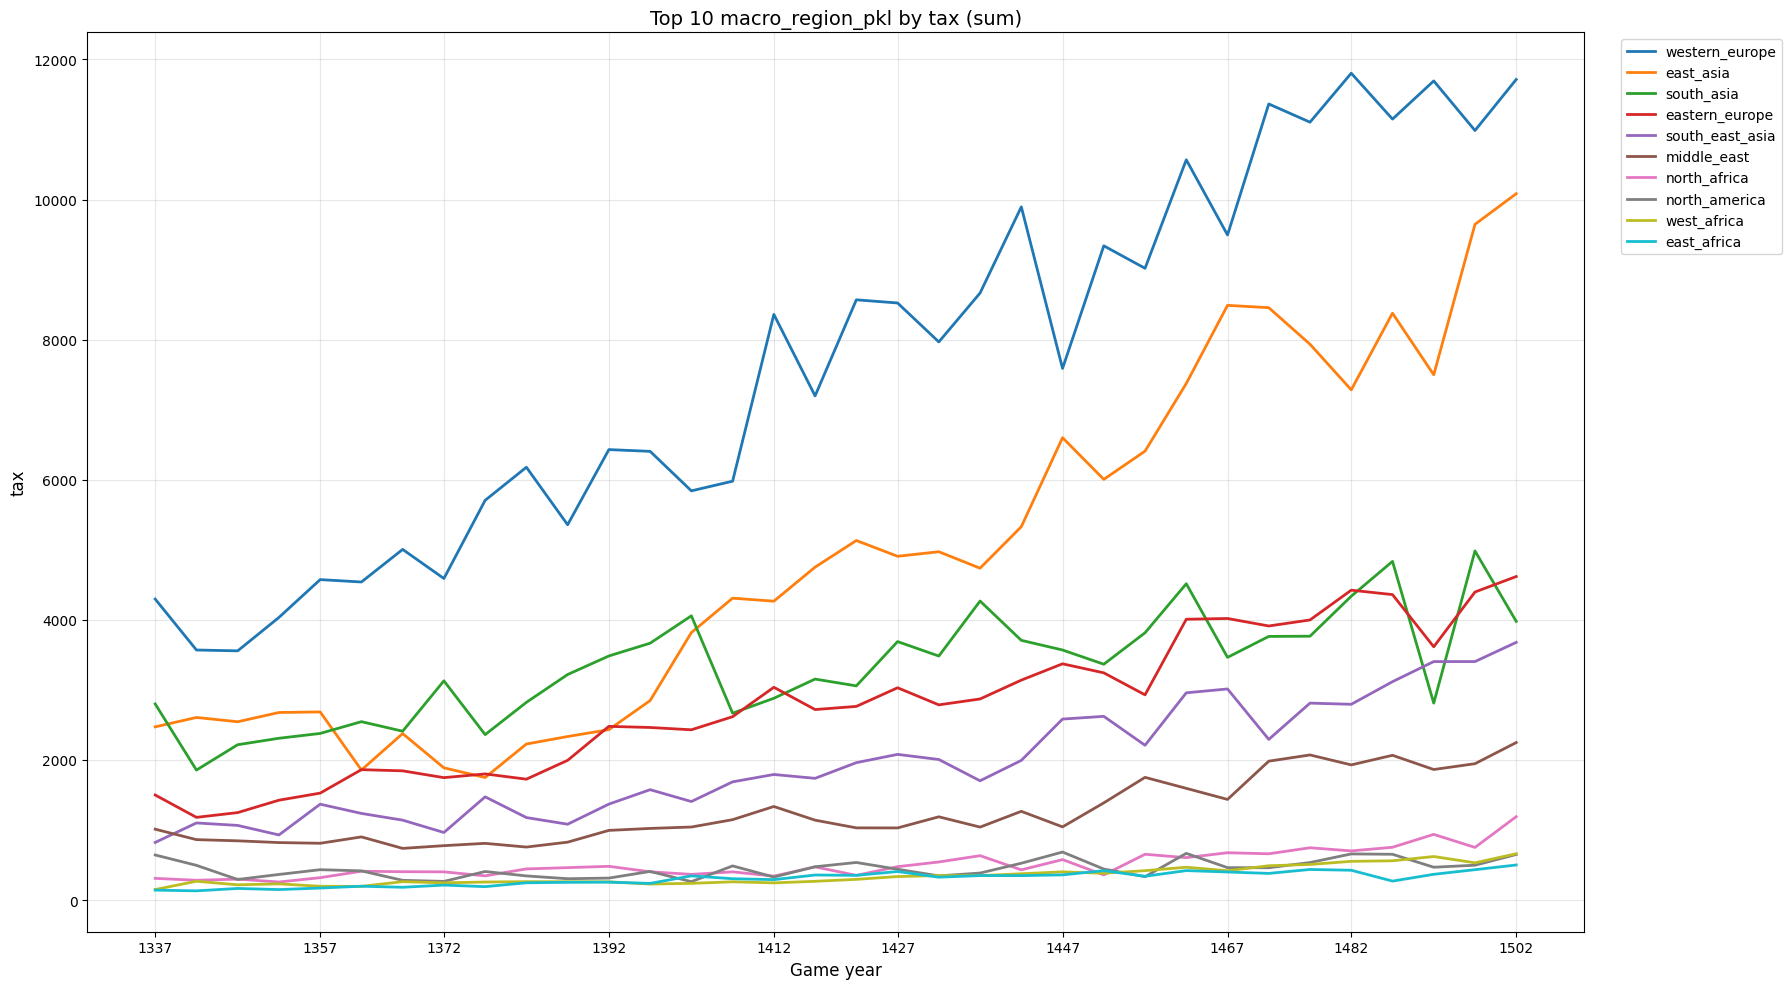

In [15]:
import matplotlib.pyplot as plt

# Plot: x = snapshots (ordered), y = metric, one line per top-N group
# Each pkl = 5 game years; ~10 x-ticks labeled every 50 years
years_per_snapshot = 5
start_year = 1337  # EU5 start
n_ticks = 10

plot_cols = [c for c in top_df.columns if c.startswith(f"{metric}_")]
plot_data = top_df.set_index(comparison)[plot_cols].T

# Scale to millions for population; 5e8 -> 500 mio
scale = 1e6 if metric in ("total_population", "population") else 1
plot_data = plot_data / scale
ylabel = f"{metric} (million)" if scale > 1 else metric

fig, ax = plt.subplots(figsize=(18, 10))
plot_data.plot(ax=ax, linewidth=2, markersize=4)
order_label = "Top" if order == "top" else "Bottom"
ax.set_title(f"{order_label} {n} {comparison} by {metric} ({aggregation_method})", fontsize=14)
ax.set_xlabel("Game year", fontsize=12)
ax.set_ylabel(ylabel, fontsize=12)
ax.tick_params(axis="both", labelsize=10)
ax.grid(True, axis="both", alpha=0.3, linestyle="-")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)

n = len(plot_data)
if n <= 1:
    tick_positions = list(range(n))
elif n <= n_ticks:
    tick_positions = list(range(n))
else:
    step = (n - 1) / (n_ticks - 1)
    tick_positions = [int(round(i * step)) for i in range(n_ticks)]
tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
plt.tight_layout()
plt.show()

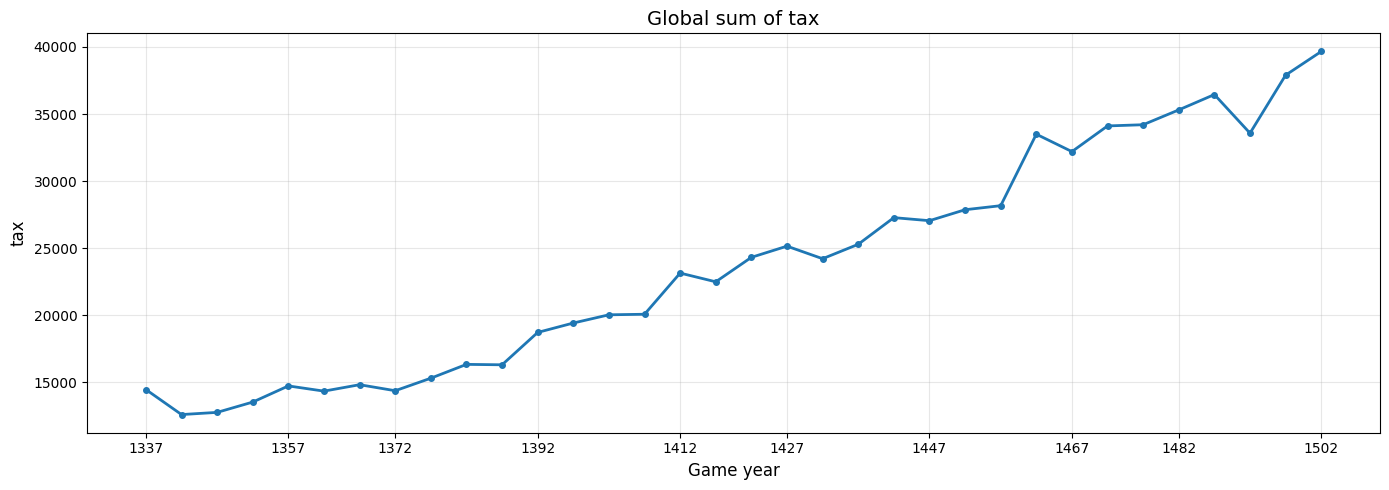

In [16]:
# Global sum of metric per snapshot (as graph)
# Use raw saves—comparison_df uses aggregation (mean/median/etc), so summing it would be wrong
labels = [c.replace(f"{metric}_", "") for c in comparison_df.columns if c.startswith(f"{metric}_")]
global_sum = pd.Series(
    {lb: saves[lb][metric].sum() for lb in labels if lb in saves and metric in saves[lb].columns}
).reindex(labels).dropna()
scale = 1e6 if metric in ("total_population", "population") else 1
y = (global_sum / scale).values
ylabel = f"{metric} (million)" if scale > 1 else metric

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(y)), y, linewidth=2, markersize=4, marker="o")
ax.set_title(f"Global sum of {metric}", fontsize=14)
ax.set_xlabel("Game year", fontsize=12)
ax.set_ylabel(ylabel, fontsize=12)
n_ticks = 10
n = len(y)
if n <= 1:
    tick_positions = list(range(n))
elif n <= n_ticks:
    tick_positions = list(range(n))
else:
    step = (n - 1) / (n_ticks - 1)
    tick_positions = [int(round(i * step)) for i in range(n_ticks)]
tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.grid(True, axis="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
"""Biggest changes (by absolute value) from first to last snapshot."""
metric_cols = [c for c in comparison_df.columns if c.startswith(f"{metric}_")]
if len(metric_cols) < 2:
    print("Need at least 2 snapshots to compute change.")
else:
    first_col, last_col = metric_cols[0], metric_cols[-1]
    change_df = comparison_df[[comparison] + [first_col, last_col]].copy()
    change_df["_change"] = change_df[last_col] - change_df[first_col]
    change_df = change_df.rename(columns={first_col: "start", last_col: "end"})
    mask = change_df["start"] != 0
    change_df["pct_change"] = float("inf")
    change_df.loc[mask, "pct_change"] = (
        (change_df.loc[mask, "end"] - change_df.loc[mask, "start"])
        / change_df.loc[mask, "start"]
        * 100
    )
    change_df = change_df[change_df["_change"] != 0]

    # Scale millions to thousands, no decimals
    for col in ("start", "end", "_change"):
        change_df[col] = (change_df[col] / 1000).astype(int)

    n_change = min(n, len(change_df))
    display(change_df.reindex(change_df["_change"].abs().sort_values(ascending=False).index).head(n_change))

,macro_region_pkl,start,end,_change,pct_change
5,east_asia,2,10,7,307.888350
22,western_europe,4,11,7,172.672253
6,eastern_europe,1,4,3,208.072048
18,south_east_asia,0,3,2,347.445255
8,middle_east,1,2,1,122.354105
16,south_asia,2,3,1,42.122186
4,east_africa,0,0,0,254.609929
2,central_africa,0,0,0,300.000000
10,north_america,0,0,0,1.088647
9,north_africa,0,1,0,285.113269
